## Decision Tree Model Training and Evaluation ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

**Loading Dataset**

In [2]:
df = pd.read_csv("../Dataset/cleaned_gcs_kushal.csv")
df.head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,endoscopic_images,biopsy_results,ct_scan,...,label,existing_conditions_Chronic Gastritis,existing_conditions_Diabetes,existing_conditions_Unknown,mature_mirna_id_MIR123_1,mature_mirna_id_MIR234_2,mature_mirna_id_MIR345_3,target_symbol_CDH1,target_symbol_KRAS,target_symbol_TP53
0,43,1,1,0,0,0,0,0,0,0,...,0,True,False,False,True,False,False,False,False,True
1,86,0,1,0,0,1,1,0,0,0,...,0,False,True,False,False,True,False,False,False,True
2,68,1,0,1,1,0,1,0,0,0,...,0,False,False,True,False,False,True,False,True,False
3,57,0,0,0,0,1,1,0,0,0,...,0,True,False,False,True,False,False,False,True,False
4,33,1,0,1,1,0,1,1,0,0,...,0,False,True,False,True,False,False,True,False,False


### Features and Target ###

In [3]:
X = df.drop("label", axis=1)
y = df["label"]

### Training and Testing Data ###

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape

((169883, 29), (42471, 29))

### 1. Default Decision Tree Classifier (Baseline) ###

In [5]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

print("--- Train Classification Report (Default) ---")
print(classification_report(y_train, dt_default.predict(X_train)))
print("--- Test Classification Report (Default) ---")
print(classification_report(y_test, dt_default.predict(X_test)))

--- Train Classification Report (Default) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    153116
           1       1.00      1.00      1.00     16767

    accuracy                           1.00    169883
   macro avg       1.00      1.00      1.00    169883
weighted avg       1.00      1.00      1.00    169883

--- Test Classification Report (Default) ---
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     38279
           1       0.10      0.12      0.11      4192

    accuracy                           0.81     42471
   macro avg       0.50      0.50      0.50     42471
weighted avg       0.82      0.81      0.81     42471



### 2. Mitigated Decision Tree Classifier (Class Balanced + Regularized) ###

In [6]:
# Address class imbalance using class_weight='balanced' and apply regularization
dt_mitigated = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    min_samples_leaf=100,
    random_state=42
)
dt_mitigated.fit(X_train, y_train)

print("--- Train Classification Report (Mitigated) ---")
print(classification_report(y_train, dt_mitigated.predict(X_train)))
print("--- Test Classification Report (Mitigated) ---")
print(classification_report(y_test, dt_mitigated.predict(X_test)))

--- Train Classification Report (Mitigated) ---
              precision    recall  f1-score   support

           0       0.91      0.40      0.56    153116
           1       0.10      0.63      0.18     16767

    accuracy                           0.42    169883
   macro avg       0.51      0.51      0.37    169883
weighted avg       0.83      0.42      0.52    169883

--- Test Classification Report (Mitigated) ---
              precision    recall  f1-score   support

           0       0.90      0.40      0.55     38279
           1       0.10      0.61      0.17      4192

    accuracy                           0.42     42471
   macro avg       0.50      0.50      0.36     42471
weighted avg       0.82      0.42      0.51     42471



### 3. Classification Threshold Curves ###

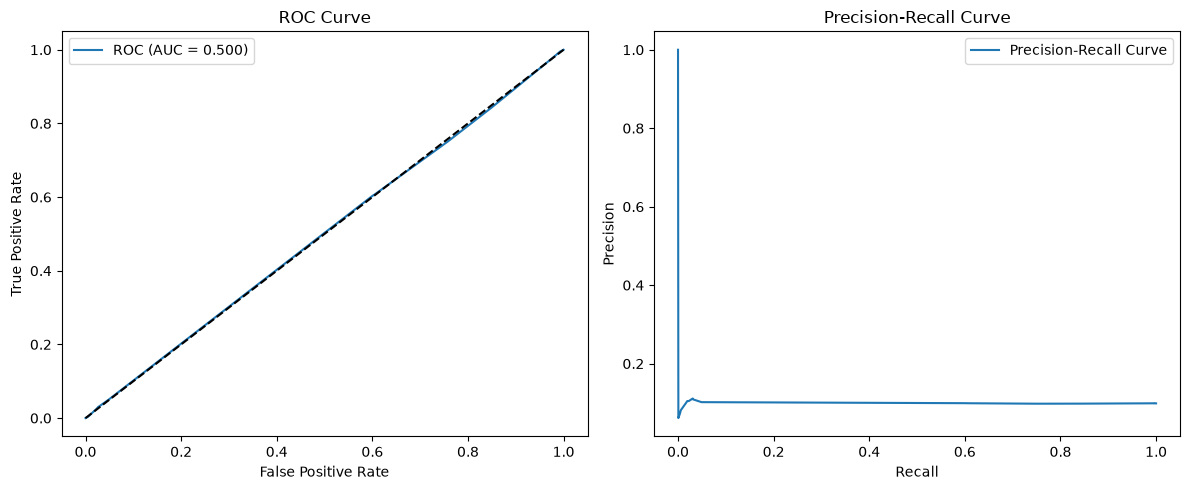

In [7]:
y_prob = dt_mitigated.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

### 4. Tuning Decision Threshold for F1-Score ###

In [8]:
best_threshold = 0.5
best_f1 = 0
for threshold in np.linspace(0.01, 0.99, 100):
    preds = (y_prob >= threshold).astype(int)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    f1 = report['1']['f1-score']
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Optimal Threshold for F1-Score: {best_threshold:.3f}")
print(f"Best test F1-score achieved: {best_f1:.3f}")

y_pred_tuned = (y_prob >= best_threshold).astype(int)
print("\n--- Test Classification Report with Tuned Threshold ---")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

Optimal Threshold for F1-Score: 0.327
Best test F1-score achieved: 0.180

--- Test Classification Report with Tuned Threshold ---
              precision    recall  f1-score   support

           0       0.94      0.01      0.01     38279
           1       0.10      1.00      0.18      4192

    accuracy                           0.10     42471
   macro avg       0.52      0.50      0.10     42471
weighted avg       0.85      0.10      0.03     42471



### 5. Feature Importance ###

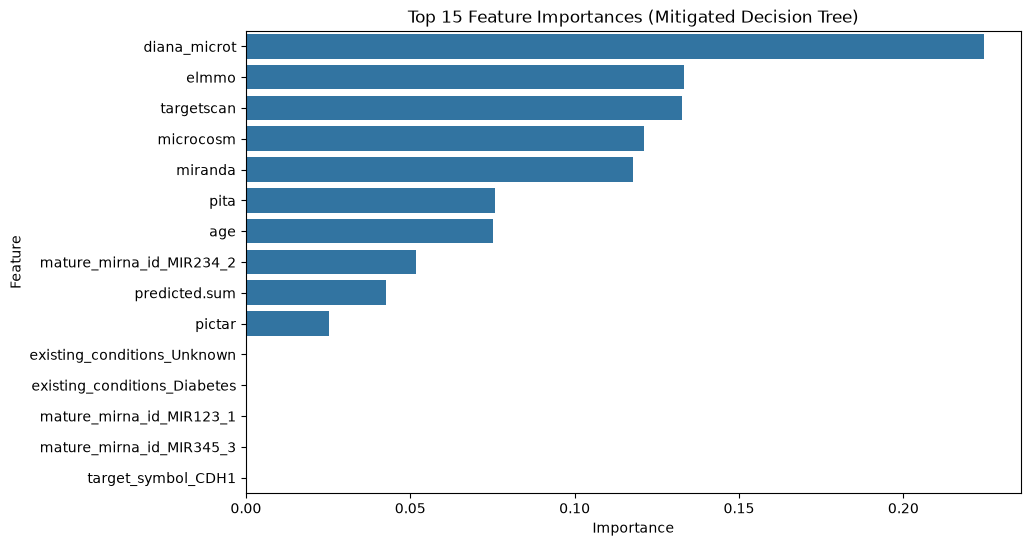

In [9]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_mitigated.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(15))
plt.title("Top 15 Feature Importances (Mitigated Decision Tree)")
plt.show()